#### **NEM Review**

# Market-making obligation: ASX trading

## Prepare environment and data

In [1]:
# Data handling
import geopandas as gpd
import numpy as np
import os
import pandas as pd
import pyarrow.compute as pc

# Visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Custom functions
from scripts.common_functions import python_setup, get_mms_data, save_figure

# Set up Python
working_dir, charts_dir, data_dir = python_setup(2, dark_mode=False)

# Variables
regions = ["NSW", "QLD", "SA", "VIC"]
quarters = ["Q1", "Q2", "Q3", "Q4"]

# Load ASX volumes
raw_asx_data = pd.read_csv(
    os.path.join(data_dir, "asx_data", "asx_data.csv"),
    parse_dates=[0],
    index_col=0)

# Convert index to just the date
raw_asx_data.index = raw_asx_data.index.floor('D')

# Sort the index
raw_asx_data.sort_index(inplace=True)

# Reshape the data using melt
asx_data = raw_asx_data.melt(
    ignore_index=False,
    var_name="Column",
    value_name="Value"
).dropna()

# Split column into its components
asx_data[["Region", "Year", "Period_Contract_Metric"]] = asx_data["Column"].str.split(" ", n=2, expand=True)

# Further split "Period_Contract_Metric" into "Period", "Contract", and "Metric"
split_data = asx_data["Period_Contract_Metric"].str.split(" ", n=2, expand=True)
split_data.columns = ["Period_Temp", "Contract_Temp", "Metric"]

# Extract "Period" and "Contract"
asx_data["Period"] = np.where(
    split_data["Period_Temp"].str.contains("Calendar"),
    "calendar",
    np.where(
        split_data["Period_Temp"].str.contains("Financial"),
        "financial",
        split_data["Period_Temp"]))
asx_data["Contract"] = np.where(
    split_data["Contract_Temp"].str.contains("Base"),
    "base",
    "cap")
asx_data["Metric"] = np.where(
    split_data["Metric"].str.contains("Volume"),
    "volume",
    "open interest")

# Drop temporary columns
asx_data.drop(columns=["Column", "Period_Contract_Metric"], inplace=True)

# Reorder columns
asx_data.reset_index(inplace=True)
asx_data = asx_data[["Date", "Region", "Period", "Contract", "Metric", "Value"]]
asx_data

,Date,Region,Period,Contract,Metric,Value
0,2021-07-01,NSW,Q3,cap,volume,0.0
1,2021-07-02,NSW,Q3,cap,volume,0.0
2,2021-07-05,NSW,Q3,cap,volume,0.0
3,2021-07-06,NSW,Q3,cap,volume,0.0
4,2021-07-07,NSW,Q3,cap,volume,0.0
...,...,...,...,...,...,...
362239,2025-06-24,VIC,financial,cap,open interest,0.0
362240,2025-06-25,VIC,financial,cap,open interest,0.0
362241,2025-06-26,VIC,financial,cap,open interest,0.0
362242,2025-06-27,VIC,financial,cap,open interest,0.0


In [2]:
# SA cap volumes
sa_raw_data = pd.read_csv(
    os.path.join(data_dir, "asx_data", "sa_cap_volumes.csv"),
    parse_dates=[0],
    index_col=0)
sa_raw_data.index.name = "Date"
sa_raw_data.index = sa_raw_data.index.normalize()
sa_raw_data = sa_raw_data.melt(
    ignore_index=False,
    var_name="Column",
    value_name="Value").dropna()
sa_raw_data[["Year", "Period", "Column"]] = sa_raw_data["Column"].str.split(" ", n=6, expand=True).iloc[:, 4:]
sa_raw_data = sa_raw_data.iloc[:, [2, 3, 1]]
sa_raw_data["Year"] = sa_raw_data["Year"].astype(int)
sa_raw_data.sort_index(inplace=True)
sa_raw_data = sa_raw_data[sa_raw_data["Value"] > 0]

# Reformat
sa_caps = pd.DataFrame(
    columns=["Volume"],
    index=pd.date_range("2020-01-01", "2025-07-01", freq="QE"))
sa_caps.index.name = "Quarter"

for i, row in sa_raw_data.iterrows():
    period = row["Period"]
    year = int(row["Year"])
    value = float(row["Value"])
    if "Q" in period:
        month = int(period[-1]) * 3
        quarter = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd()
        if pd.isna(sa_caps.at[quarter, "Volume"]):
            sa_caps.at[quarter, "Volume"] = value
        else:
            sa_caps.at[quarter, "Volume"] = sa_caps.at[quarter, "Volume"] + value
    elif period == "Calendar":        
        quarter = [q for q in pd.date_range(f"{year}", periods=4, freq="QE") if q < pd.to_datetime("2025-07-01")]
        for q in quarter:
            if pd.isna(sa_caps.at[q, "Volume"]):
                sa_caps.at[q, "Volume"] = value
            else:
                sa_caps.at[q, "Volume"] = sa_caps.at[q, "Volume"] + value
    else:
        quarter = [q for q in pd.date_range(f"{year - 1}-06-30", periods=4, freq="QE") if q < pd.to_datetime("2025-07-01") and q > pd.to_datetime("2019-12-31")]

sa_caps.at[pd.Timestamp("2019-12-31"), "Volume"] = sa_caps.iat[0, 0]
sa_caps.sort_index(inplace=True)

In [3]:
sa_demand = get_mms_data(
    "collect_sa_peak_demand",
    {"start_date": "2020-01-01",
     "end_date": "2025-06-30"})
sa_demand["Day"] = sa_demand["Day"].map(pd.to_datetime)
sa_demand["Quarter"] = sa_demand["Day"].dt.to_period("Q").dt.to_timestamp() + pd.offsets.QuarterEnd()

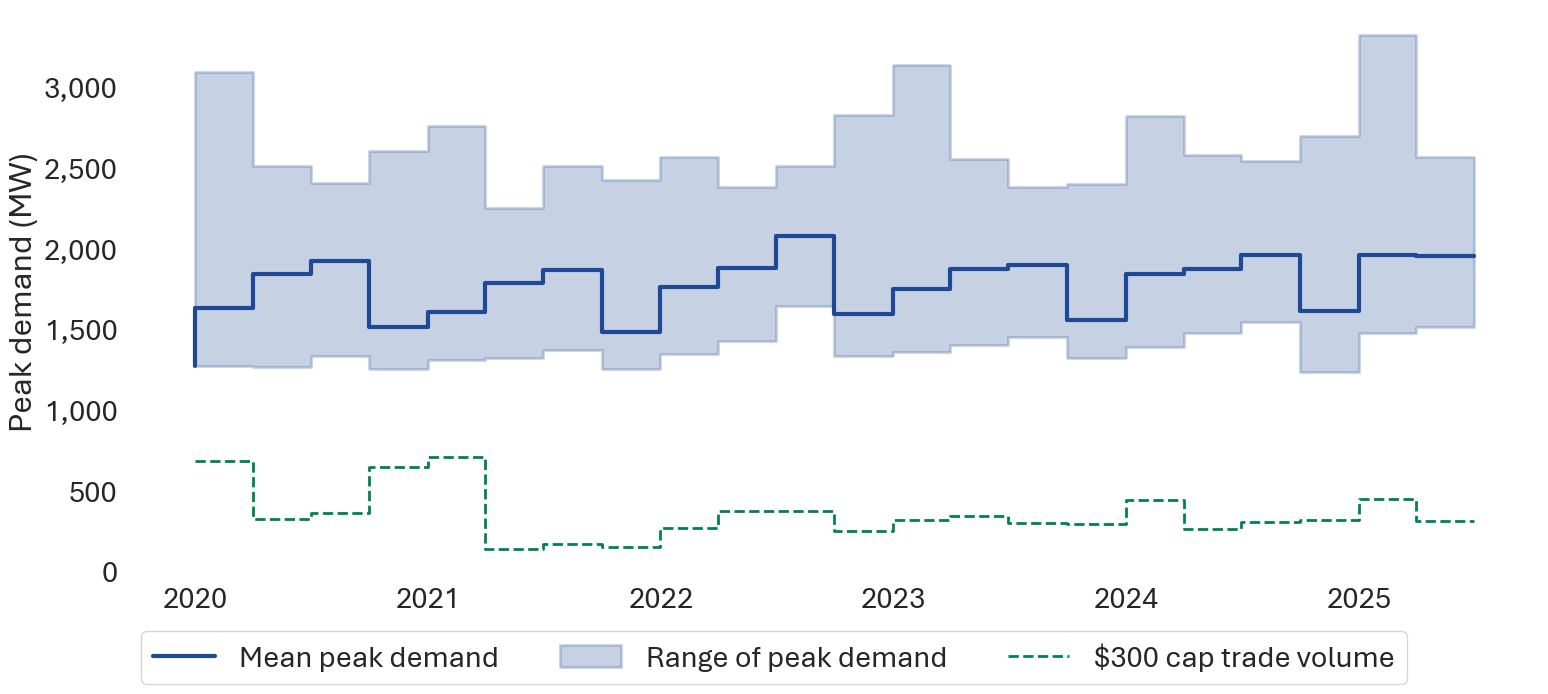

In [38]:
chart_data = sa_demand.pivot_table(
    index="Quarter",
    values="Peak demand",
    aggfunc=["min", "mean", "max"])
chart_data.loc[pd.Timestamp("2019-12-31")] = chart_data.iloc[0, 0]
chart_data.sort_index(inplace=True)
fig, ax = plt.subplots(
    figsize=(16, 6.75),
    tight_layout=True)
ax.step(
    x=chart_data.index,
    y=chart_data[("mean", "Peak demand")],
    where="pre",
    linewidth=3,
    color="C1",
    label="Mean peak demand")
ax.fill_between(
    x=chart_data.index,
    y1=chart_data[("min", "Peak demand")],
    y2=chart_data[("max", "Peak demand")],
    step="pre",
    linewidth=2,
    color="C1",
    alpha=0.25,
    label="Range of peak demand")
ax.step(
    x=sa_caps.index,
    y=sa_caps["Volume"],
    where="pre",
    linewidth=2,
    color="C2",
    linestyle="--",
    label="$300 cap trade volume")
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.075), ncol=3)
for frame in ["top", "right", "bottom", "left"]:
    ax.spines[frame].set_visible(False)
plt.ylabel("Peak demand (MW)")
ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
plt.show()
save_figure(fig, f"SA_peak_demand_cap_volumes", charts_dir)

In [39]:
1 / (chart_data[("mean", "Peak demand")] / sa_caps["Volume"]).mean()

np.float64(0.17433455239296597)

In [5]:
# Price spread data
raw_price_spreads = pd.read_csv(
    os.path.join(data_dir, "asx_data", "price_spreads.csv"),
    parse_dates=[0],
    index_col=0)
raw_price_spreads.index.name = "Date"
raw_price_spreads.index = raw_price_spreads.index.normalize()
raw_price_spreads = raw_price_spreads.melt(
    ignore_index=False)
raw_price_spreads[["Region", "Year", "Quarter", "Contract"]] = raw_price_spreads["variable"].str.split(" ", n=6, expand=True).iloc[:, 3:]
raw_price_spreads["Contract"] = np.where(
    raw_price_spreads["Contract"].str.contains("Base"),
    "Baseload",
    "Cap")
raw_price_spreads = raw_price_spreads.iloc[:, [2, 5, 3, 4, 1]].rename(columns={"value": "Price"}).reset_index()

In [6]:
# Analysis results
spreads = raw_price_spreads.pivot_table(
    index="Date",
    columns=["Contract", "Region", "Year", "Quarter"])

# Capture results
for region in regions:
    for contract in ["Cap", "Baseload"]:
        for year in range(2020, 2030):
            for quarter in quarters:
                # Extract prices for that quarter's contract
                if (year == 2029) & (quarter == "Q3"):
                    break
                else:
                    price_series = spreads[("Price", contract, region, str(year), quarter)].dropna()
                    price_movement = price_series.pct_change().dropna()                
                    # Prepare results
                    temp_df = pd.DataFrame({
                        "Contract": contract,
                        "Region": region,
                        "Year": year,
                        "Quarter": quarter,
                        "Price": price_series.iloc[1:],
                        "Price movement": price_movement.values})                        
                    # Combine results
                    if "results" in locals() or "results" in globals():
                        results = pd.concat([results, temp_df], ignore_index=True)
                    else:
                        results = temp_df.copy()
results["Price movement"] = results["Price movement"].abs()
results

,Contract,Region,Year,Quarter,Price,Price movement
0,Cap,NSW,2020,Q1,10.50,0.125000
1,Cap,NSW,2020,Q1,27.25,1.595238
2,Cap,NSW,2020,Q1,25.75,0.055046
3,Cap,NSW,2020,Q1,24.05,0.066019
4,Cap,NSW,2020,Q1,24.00,0.002079
...,...,...,...,...,...,...
170451,Baseload,VIC,2029,Q2,89.94,0.000000
170452,Baseload,VIC,2029,Q2,89.94,0.000000
170453,Baseload,VIC,2029,Q2,89.94,0.000000
170454,Baseload,VIC,2029,Q2,89.94,0.000000


Cap


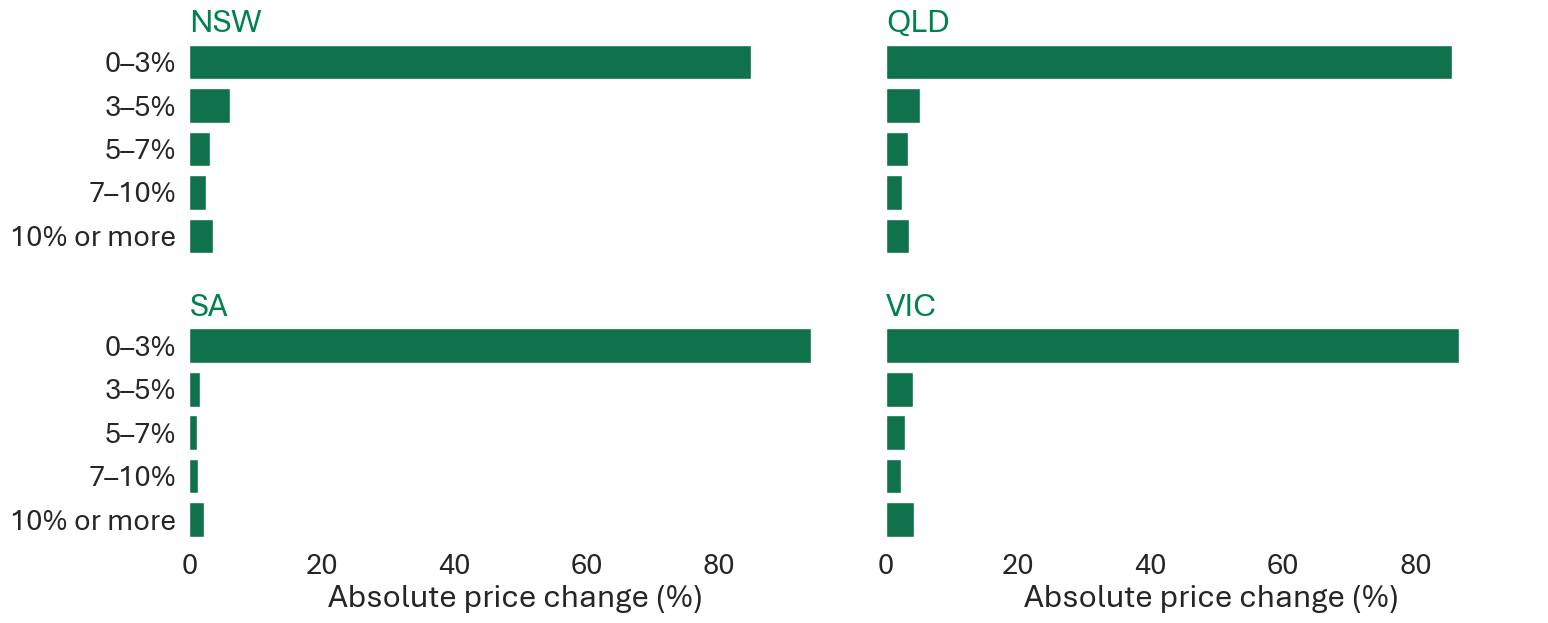

Baseload


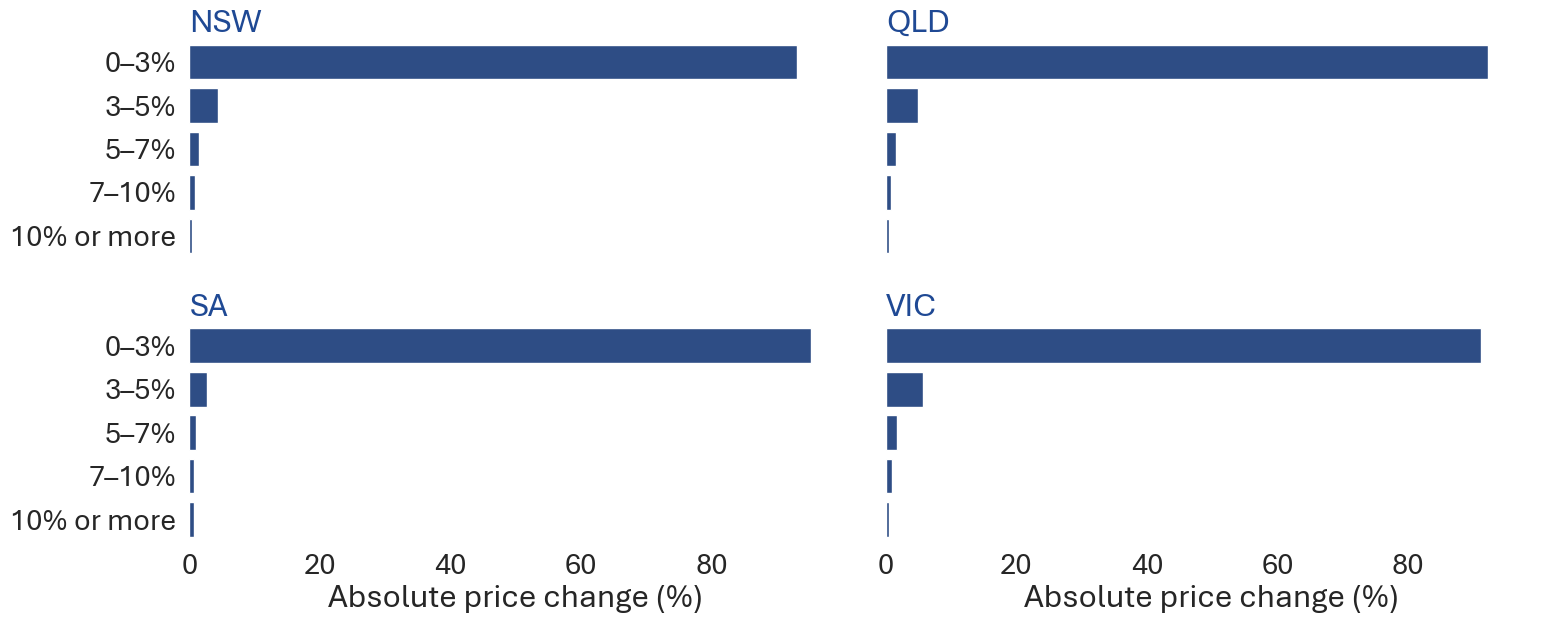

In [7]:
bins = [0, 0.03, 0.05, 0.07, 0.10, float("inf")]
labels = ["0–3%", "3–5%", "5–7%", "7–10%", "10% or more"]

for contract in ["Cap", "Baseload"]:    
    print(contract)
    contract_data = results[
        results["Contract"] == contract].copy()
    fig, ax = plt.subplots(
        2, 2,
        figsize=(16, 6.75),
        tight_layout=True,
        sharex=True,
        sharey=True)
    for i, region in enumerate(regions):
        axis = ax[i // 2, i % 2]
        region_data = contract_data[
            contract_data["Region"] == region].copy()
        region_data["Movement"] = pd.cut(region_data["Price movement"], bins=bins, labels=labels, right=False)
        region_data = region_data["Movement"].value_counts().loc[labels]
        region_data = region_data / region_data.sum()
        sns.barplot(
            ax=axis,
            data=region_data,
            orient="h",
            color=("C1" if contract == "Baseload" else "C2"))
        for frame in ["top", "right", "bottom", "left"]:
            axis.spines[frame].set_visible(False)
        axis.set_title(region, loc="left", color=("C1" if contract == "Baseload" else "C2"))
        axis.set_ylabel(None)
        axis.set_xlabel("Absolute price change (%)")
        axis.xaxis.set_major_formatter(lambda x, p: f"{x * 100:.0f}")
    plt.show()
    save_figure(fig, f"{contract.lower()}_daily_price_movements", charts_dir)

In [8]:
for region in regions:
    print(region)
    capture_results = pd.DataFrame()
    region_data = results[
        results["Region"] == region].copy()
    for contract in ["Baseload", "Cap"]:
        contract_data = region_data[
            region_data["Contract"] == contract].copy()
        for year in range(2020, 2030):
            year_data = contract_data[
                contract_data["Year"] == year].copy()
            year_data["Movement"] = pd.cut(year_data["Price movement"], bins=bins, labels=labels, right=False)
            year_data = year_data["Movement"].value_counts().loc[labels]
            # year_data = year_data / year_data.sum()
            for index, value in year_data.items():
                capture_results.loc[year, index] = value
            capture_results.index.name = "Year"
            capture_results.to_csv(os.path.join(data_dir, f"{region}_{contract.lower()}_price_movement_distributions.csv"))

NSW
QLD
SA
VIC


NSW


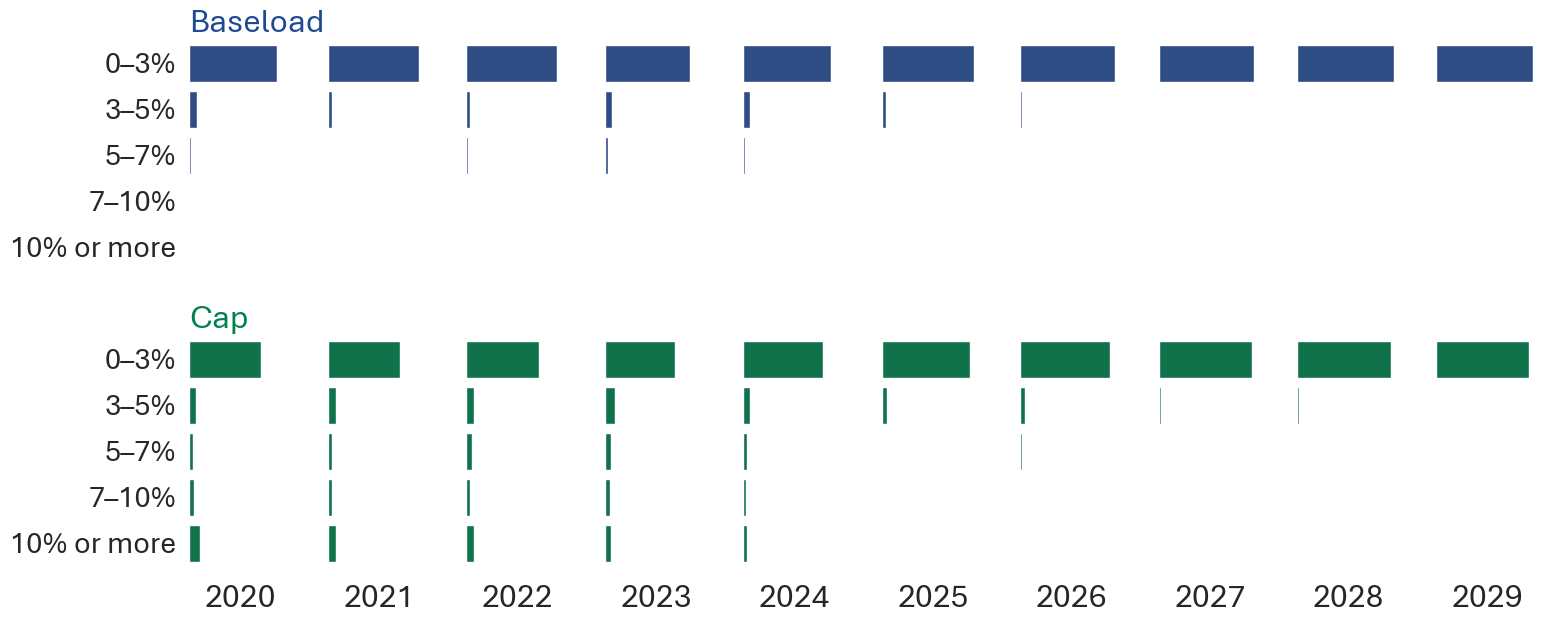

QLD


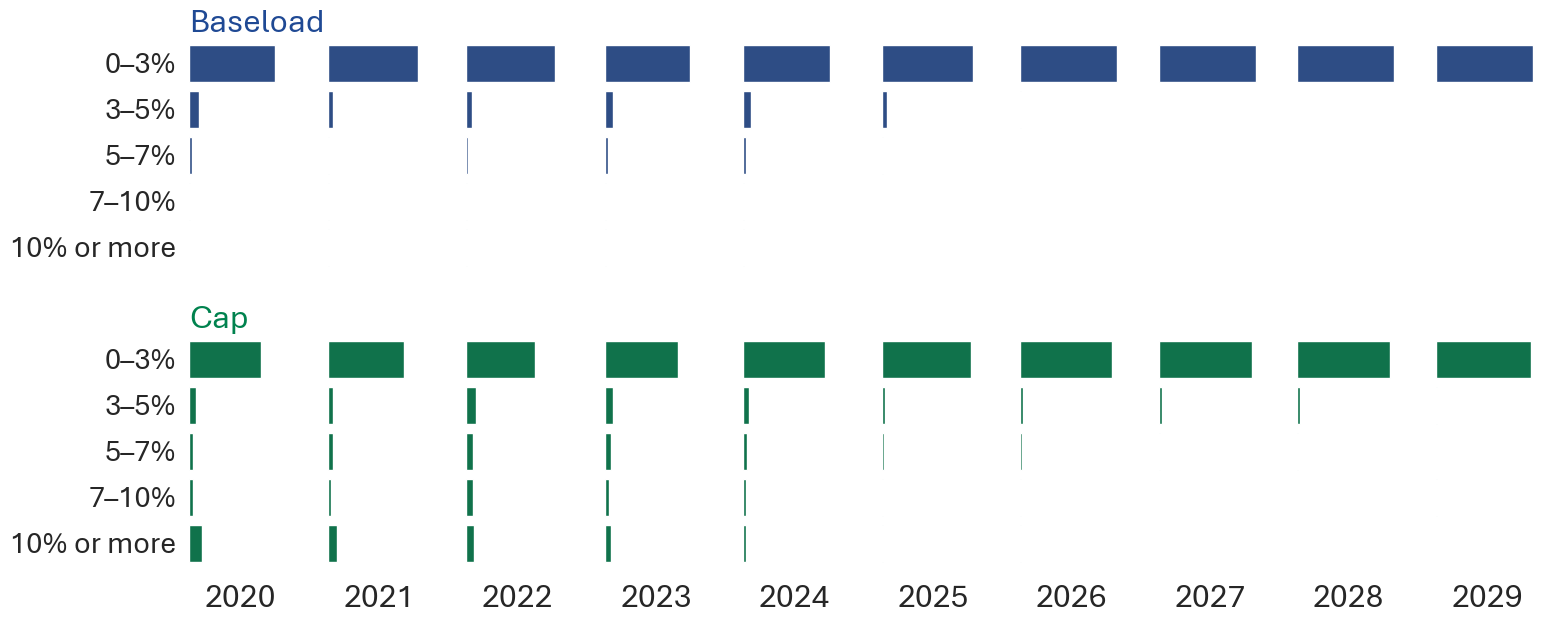

SA


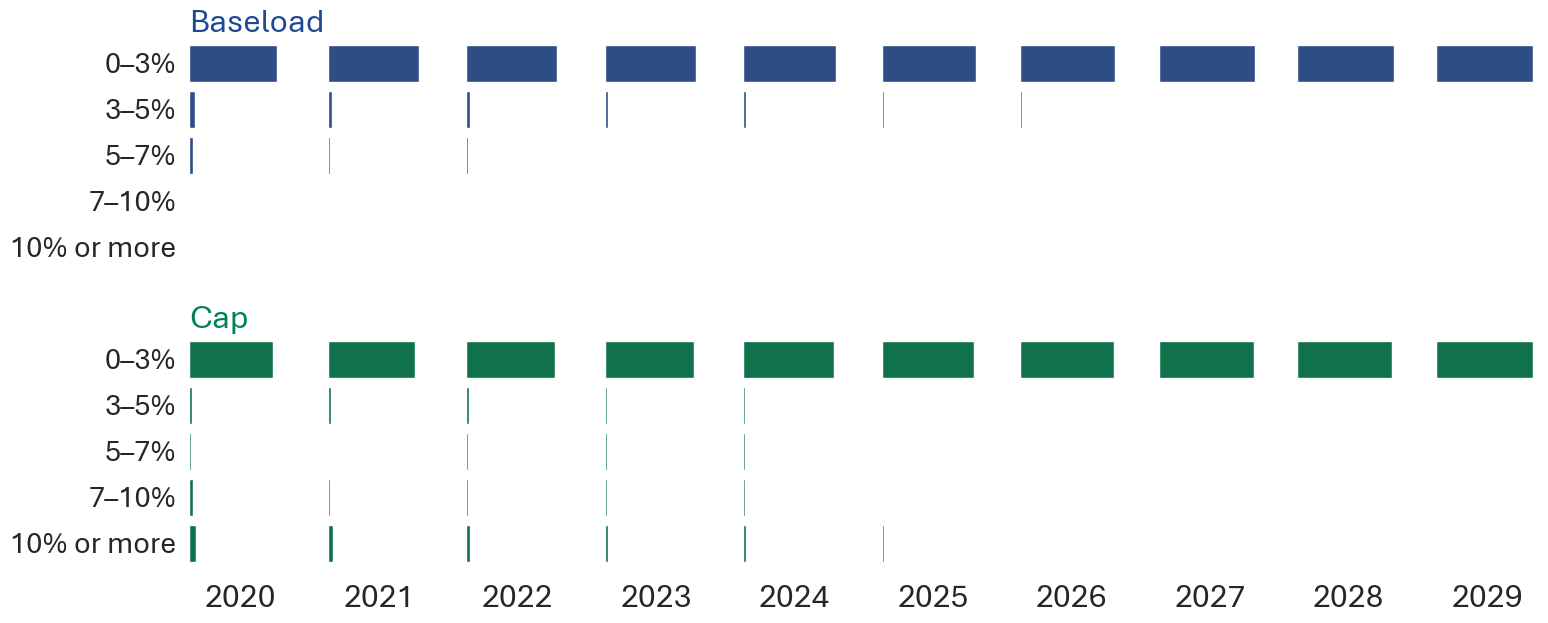

VIC


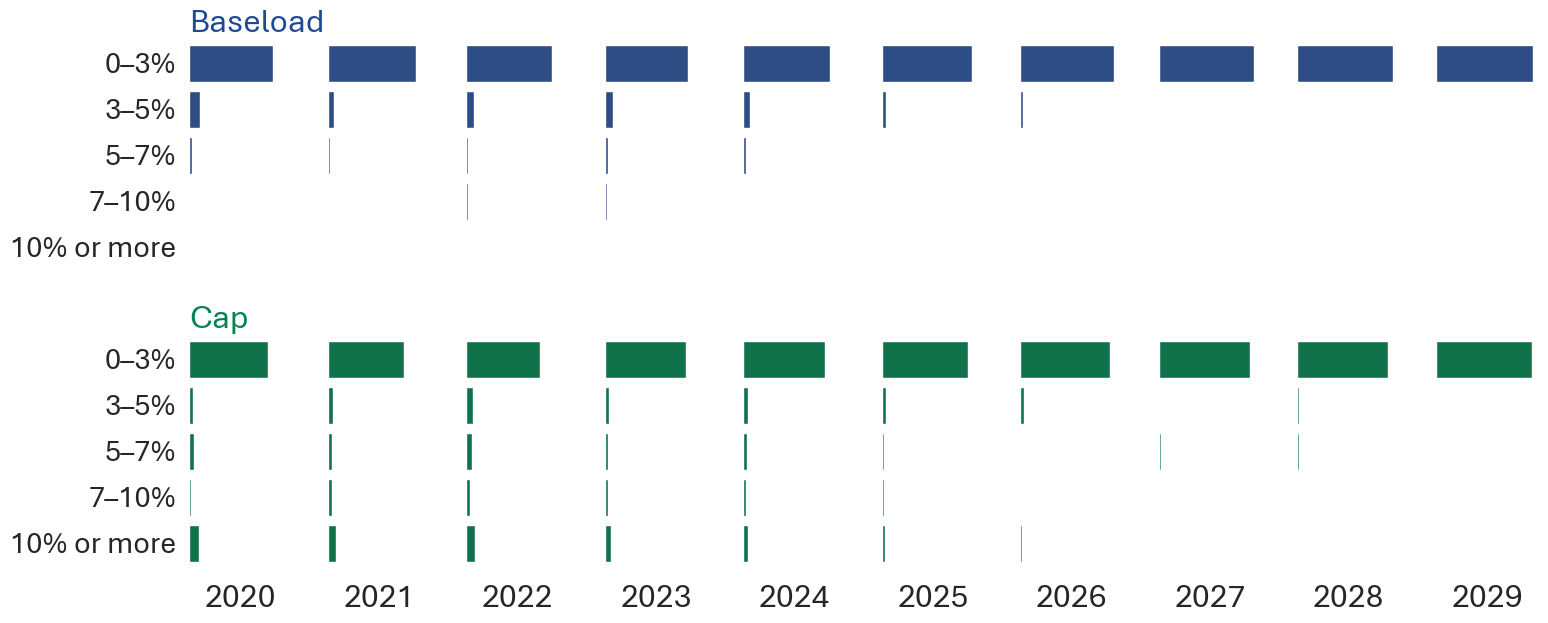

In [9]:
for region in regions:
    print(region)    
    fig, ax = plt.subplots(
        2, 10,
        figsize=(16, 6.75),
        tight_layout=True,
        sharex=True,
        sharey=True)
    region_data = results[
        results["Region"] == region].copy()
    for c, contract in enumerate(["Baseload", "Cap"]):
        contract_data = region_data[
            region_data["Contract"] == contract].copy()
        for y, year in enumerate(range(2020, 2030)):
            axis = ax[c, y]
            year_data = contract_data[
                contract_data["Year"] == year].copy()
            year_data["Movement"] = pd.cut(year_data["Price movement"], bins=bins, labels=labels, right=False)
            year_data = year_data["Movement"].value_counts().loc[labels]
            year_data = year_data / year_data.sum()
            sns.barplot(
                ax=axis,
                data=year_data,
                orient="h",
                color=("C1" if contract == "Baseload" else "C2"))
            for frame in ["top", "right", "bottom", "left"]:
                axis.spines[frame].set_visible(False)
            axis.set_title((contract if y == 0 else None), loc="left", color=("C1" if contract == "Baseload" else "C2"))
            axis.set_ylabel(None)
            axis.set_xticks(axis.get_xticks())
            axis.set_xticklabels(axis.get_xticklabels())
            axis.set_xlabel(year)
    plt.show()
    save_figure(fig, f"{region}_daily_price_movements_2020_to_2029", charts_dir)

In [10]:
for contract in ["Baseload", "Cap"]:
    for threshold in [0.05, 0.1]:
        data = results[
            results["Contract"] == contract]
        test = (data["Price movement"] < threshold).sum() / len(data)
        print(contract, f"{threshold:.0%}", f"{test:.1%}")

Baseload 5% 97.3%
Baseload 10% 99.5%
Cap 5% 92.0%
Cap 10% 96.7%


In [11]:
for contract in ["Baseload", "Cap"]:
    for threshold in [0.05, 0.1]:
        for region in regions:        
            data = results[
                (results["Contract"] == contract) &
                (results["Region"] == region)]
            test = (data["Price movement"] < threshold).sum() / len(data)
            print(contract, region, f"{threshold:.0%}", f"{test:.1%}")

Baseload NSW 5% 97.4%
Baseload QLD 5% 97.2%
Baseload SA 5% 97.7%
Baseload VIC 5% 96.8%
Baseload NSW 10% 99.6%
Baseload QLD 10% 99.6%
Baseload SA 10% 99.3%
Baseload VIC 10% 99.5%
Cap NSW 5% 91.0%
Cap QLD 5% 90.7%
Cap SA 5% 95.5%
Cap VIC 5% 90.7%
Cap NSW 10% 96.4%
Cap QLD 10% 96.5%
Cap SA 10% 97.9%
Cap VIC 10% 95.8%


In [12]:
for contract in ["Baseload", "Cap"]:
    for threshold in [0.05, 0.1]:
        # for region in regions:
        for year in range(2020, 2030):
            data = results[
                (results["Contract"] == contract) &
                # (results["Region"] == region) &
                (results["Year"] == year)]
            test = (data["Price movement"] < threshold).sum() / len(data)
            print(contract, year, f"{threshold:.0%}", f"{test:.1%}")

Baseload 2020 5% 96.8%
Baseload 2021 5% 96.9%
Baseload 2022 5% 96.5%
Baseload 2023 5% 95.0%
Baseload 2024 5% 96.4%
Baseload 2025 5% 97.9%
Baseload 2026 5% 99.0%
Baseload 2027 5% 99.5%
Baseload 2028 5% 99.2%
Baseload 2029 5% 100.0%
Baseload 2020 10% 99.8%
Baseload 2021 10% 99.4%
Baseload 2022 10% 99.2%
Baseload 2023 10% 99.1%
Baseload 2024 10% 99.5%
Baseload 2025 10% 99.6%
Baseload 2026 10% 99.8%
Baseload 2027 10% 99.9%
Baseload 2028 10% 99.7%
Baseload 2029 10% 100.0%
Cap 2020 5% 83.0%
Cap 2021 5% 85.0%
Cap 2022 5% 84.2%
Cap 2023 5% 86.4%
Cap 2024 5% 90.5%
Cap 2025 5% 94.7%
Cap 2026 5% 96.8%
Cap 2027 5% 97.4%
Cap 2028 5% 97.7%
Cap 2029 5% 99.0%
Cap 2020 10% 89.8%
Cap 2021 10% 92.1%
Cap 2022 10% 93.2%
Cap 2023 10% 94.5%
Cap 2024 10% 96.5%
Cap 2025 10% 97.9%
Cap 2026 10% 99.0%
Cap 2027 10% 99.3%
Cap 2028 10% 99.1%
Cap 2029 10% 100.0%
